In [67]:
# === 0) Imports & utils ===
# (Si algo falta: descomenta la siguiente línea)
# !pip -q install networkx scikit-learn scikit-learn-extra pyarrow fastparquet

import os, math, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx

from sklearn.cluster import KMeans
try:
    from sklearn_extra.cluster import KMedoids
except Exception:
    KMedoids = None

import matplotlib.pyplot as plt

OUT_DIR = Path("/content/outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)

def ls_content():
    print("Archivos en /content:")
    for p in sorted(Path("/content").glob("*")):
        print("-", p)

ls_content()


Archivos en /content:
- /content/.config
- /content/.ipynb_checkpoints
- /content/df_all_procesado.parquet
- /content/df_all_reducido_github.parquet
- /content/flujos_macro_macro_k4.csv
- /content/manhattan_zonas_con_macrozona_k4.csv
- /content/outputs
- /content/sample_data
- /content/vecindad_macro_k4_flujo.csv
- /content/vecindad_macro_k4_geo.csv
- /content/vecindad_macro_k4_union.csv
- /content/viajes_manhattan_macrozonas_filtrados_k4.csv


In [68]:
# ===== 1) Cargar =====
PATH_TRIPS = "/content/viajes_manhattan_macrozonas_filtrados_k4.csv"
PATH_Z2M   = "/content/manhattan_zonas_con_macrozona_k4.csv"          # opcional
PATH_FLOWS = "/content/flujos_macro_macro_k4.csv"                     # validación
PATH_VECI  = "/content/vecindad_macro_k4_union.csv"                   # o vecindad_macro_k4_flujo.csv

# >>> Ajusta estos nombres si tus columnas son distintas <<<
COL_PICKUP_TIME = "pickup_datetime"    # si no existe, cambia al correcto
COL_TRIP_MIN    = "trip_time_min"      # si no existe, pon None y lo omitimos
COL_PU_MACRO    = "pickup_macro"
COL_DO_MACRO    = "dropoff_macro"

df = pd.read_csv(PATH_TRIPS)
print("trips:", df.shape)
df.head(3)


trips: (3793, 8)


,PUlocationID,DOlocationID,n_viajes,pct,pct_acum,frecuente_80,macrozona_origen,macrozona_destino
0,237.0,236.0,1960,0.006685,0.006685,True,1,1
1,236.0,237.0,1654,0.005642,0.012327,True,1,1
2,237.0,237.0,1413,0.004820,0.017146,True,1,1


In [69]:
# === Parche para dataset agregado macro–macro (sin tiempo) ===
import pandas as pd
import numpy as np

# 1) Declara columnas reales en tu archivo:
COL_PU_MACRO = "macrozona_origen"
COL_DO_MACRO = "macrozona_destino"
COL_TRIPS    = "n_viajes"  # peso (conteo de viajes agregados)

# 2) Crea bucket único y fecha placeholder
df["bucket"] = 0
df["date"]   = "0000-00-00"

# 3) Normaliza el conteo
df[COL_TRIPS] = pd.to_numeric(df[COL_TRIPS], errors="coerce").fillna(0)

# 4) (Opcional) Si hay filas repetidas por mismo (i,j), consolida sumando viajes
df = (df.groupby([COL_PU_MACRO, COL_DO_MACRO, "bucket", "date"], as_index=False)[COL_TRIPS]
        .sum())

print(df.head())
print("Rows:", len(df))


   macrozona_origen  macrozona_destino  bucket        date  n_viajes
0                 0                  0       0  0000-00-00    104427
1                 0                  1       0  0000-00-00     36036
2                 0                  2       0  0000-00-00     26721
3                 0                  3       0  0000-00-00      1325
4                 1                  0       0  0000-00-00     30504
Rows: 16


In [70]:
# === OD percentiles y persistencia usando sumas (no .size()) ===
def od_percentiles_sum(d, p=0.7):
    # ya tenemos 'date' (placeholder) y 'bucket' (0)
    g = d.groupby([COL_PU_MACRO, COL_DO_MACRO, "bucket", "date"])[COL_TRIPS].sum().reset_index(name="trips")
    q = g.groupby([COL_PU_MACRO, COL_DO_MACRO, "bucket"])["trips"].quantile(p).reset_index()
    return q.rename(columns={"trips":"q_trips"})

def persistent_arcs_sum(d, tau=0.7):
    daily = d.groupby([COL_PU_MACRO, COL_DO_MACRO, "bucket", "date"])[COL_TRIPS].sum().reset_index(name="trips")
    daily["exist"] = (daily["trips"]>0).astype(int)
    denom = daily.groupby([COL_PU_MACRO, COL_DO_MACRO, "bucket"])["date"].nunique().reset_index(name="n_days")
    num   = daily.groupby([COL_PU_MACRO, COL_DO_MACRO, "bucket"])["exist"].sum().reset_index(name="days_with_flow")
    freq = denom.merge(num, on=[COL_PU_MACRO, COL_DO_MACRO, "bucket"])
    freq["persistence"]   = freq["days_with_flow"]/freq["n_days"]
    freq["is_persistent"] = (freq["persistence"]>=tau).astype(int)
    return freq

# === Transiciones Markov con pesos n_viajes ===
def markov_transitions_sum(d, min_prob=0.0):
    g = d.groupby([COL_PU_MACRO, "bucket", COL_DO_MACRO])[COL_TRIPS].sum().reset_index(name="trips")
    g["row_sum"] = g.groupby([COL_PU_MACRO,"bucket"])["trips"].transform("sum")
    g = g[g["row_sum"]>0]
    g["P"] = g["trips"]/g["row_sum"]
    if min_prob>0:
        g = g[g["P"]>=min_prob]
    return g[[COL_PU_MACRO, "bucket", COL_DO_MACRO, "P"]]

def entropy(p):
    p = np.asarray([x for x in p if x>0])
    return 0.0 if len(p)==0 else -(p*np.log(p)).sum()

def topk_and_entropy(markov_df, K=6, entropy_threshold=1.2, add_backup=True):
    res=[]
    for (i,h), grp in markov_df.groupby([COL_PU_MACRO, "bucket"]):
        grp = grp.sort_values("P", ascending=False).copy()
        grp["rank"] = np.arange(1, len(grp)+1)
        grp["keep"] = (grp["rank"]<=K).astype(int)
        H = entropy(grp["P"].values)
        extra = 1 if (add_backup and H>entropy_threshold and len(grp)>K) else 0
        grp.loc[grp["rank"]<=K+extra, "keep"] = 1
        grp["entropy"] = H
        res.append(grp)
    return pd.concat(res, ignore_index=True)



In [71]:
# === Hiperparámetros base ===
P_CUT = 0.7
TAU   = 0.7
MIN_P = 0.02
TOPK  = 6
ENTR  = 1.2

od_q    = od_percentiles_sum(df, P_CUT)
persist = persistent_arcs_sum(df, TAU)
mk      = markov_transitions_sum(df, MIN_P)
tk      = topk_and_entropy(mk, TOPK, ENTR, True)

# Candidate set SIN SLA (no tenemos p90 por viaje)
a = (mk.merge(tk[[COL_PU_MACRO,"bucket",COL_DO_MACRO,"keep"]],
              on=[COL_PU_MACRO,"bucket",COL_DO_MACRO], how="left")
        .merge(od_q, on=[COL_PU_MACRO,COL_DO_MACRO,"bucket"], how="left")
        .merge(persist[[COL_PU_MACRO,COL_DO_MACRO,"bucket","is_persistent"]],
               on=[COL_PU_MACRO,COL_DO_MACRO,"bucket"], how="left"))

a["keep_topk"]   = a["keep"].fillna(0).astype(int)
a["keep_pcut"]   = (a["q_trips"].fillna(0)>0).astype(int)
a["keep_persist"]= a["is_persistent"].fillna(0).astype(int)

a["candidate"] = ((a["keep_topk"] | a["keep_pcut"] | a["keep_persist"])).astype(int)
A_cand = a[a["candidate"]==1][[COL_PU_MACRO, COL_DO_MACRO, "bucket"]].drop_duplicates()
print("A_cand:", len(A_cand))


A_cand: 13


In [72]:
# === Comunidades + límite inter-comunidad ===
import networkx as nx
from sklearn.cluster import KMeans

def communities_from_graph(markov_df):
    G = nx.DiGraph()
    for _, r in markov_df.iterrows():
        G.add_edge(r[COL_PU_MACRO], r[COL_DO_MACRO], weight=r["P"])
    UG = G.to_undirected()
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(UG, weight="weight"))
    except Exception:
        deg = pd.DataFrame({"node":[n for n in UG.nodes()],
                            "deg":[UG.degree(n) for n in UG.nodes()]})
        k = min(4, max(2, int(np.sqrt(len(deg)))))
        km = KMeans(n_clusters=k, random_state=13).fit(deg[["deg"]])
        comms = [set(deg.loc[km.labels_==c,"node"]) for c in range(k)]
    mapping = {node:idx for idx, c in enumerate(comms) for node in c}
    return pd.DataFrame({"macro": list(mapping.keys()), "community": list(mapping.values())})

comm = communities_from_graph(mk)
mmap = dict(zip(comm["macro"], comm["community"]))
A = A_cand.copy()
A["ci"] = A[COL_PU_MACRO].map(mmap)
A["cj"] = A[COL_DO_MACRO].map(mmap)

TOP_R = 3
inter = A[A["ci"]!=A["cj"]].copy()
intra = A[A["ci"]==A["cj"]].copy()

Pmap = mk.set_index([COL_PU_MACRO,"bucket",COL_DO_MACRO])["P"]
inter["P"] = Pmap.reindex(pd.MultiIndex.from_frame(inter[[COL_PU_MACRO,"bucket",COL_DO_MACRO]])).values
inter["P"] = inter["P"].fillna(0)
inter = (inter.sort_values([COL_PU_MACRO,"bucket","P"], ascending=[True,True,False])
             .groupby([COL_PU_MACRO,"bucket"]).head(TOP_R))

A_final = pd.concat([intra[[COL_PU_MACRO, COL_DO_MACRO, "bucket"]],
                     inter[[COL_PU_MACRO, COL_DO_MACRO, "bucket"]]], ignore_index=True).drop_duplicates()
print("A_final:", len(A_final))


A_final: 13


In [73]:
# === Rebalanceo por déficit/superávit (con n_viajes agregados) ===
# Déficit esperado por macro y bucket (único)
outd = df.groupby([COL_PU_MACRO,"bucket"])[COL_TRIPS].sum().reset_index(name="out_trips")
ind  = df.groupby([COL_DO_MACRO,"bucket"])[COL_TRIPS].sum().reset_index(name="in_trips")
outd = outd.rename(columns={COL_PU_MACRO:"macro"})
ind  = ind.rename(columns={COL_DO_MACRO:"macro"})
dem  = outd.merge(ind, on=["macro","bucket"], how="outer").fillna(0)
dem["deficit"] = dem["in_trips"] - dem["out_trips"]

R = A_final.copy()
R = R.merge(dem.rename(columns={"macro":COL_PU_MACRO,"deficit":"def_i"})[[COL_PU_MACRO,"bucket","def_i"]],
            on=[COL_PU_MACRO,"bucket"], how="left")
R = R.merge(dem.rename(columns={"macro":COL_DO_MACRO,"deficit":"def_j"})[[COL_DO_MACRO,"bucket","def_j"]],
            on=[COL_DO_MACRO,"bucket"], how="left")
R = R[(R["def_i"]<0) & (R["def_j"]>0)][[COL_PU_MACRO, COL_DO_MACRO, "bucket"]].drop_duplicates()
print("Arcos de rebalanceo permitidos:", len(R))


Arcos de rebalanceo permitidos: 2


In [74]:
# === Exporta resultados ===
from pathlib import Path
OUT = Path("/content/outputs"); OUT.mkdir(exist_ok=True, parents=True)

A_cand.to_csv(OUT/"A_candidates.csv", index=False)
A_final.to_csv(OUT/"A_final.csv", index=False)
R.to_csv(OUT/"rebalance_set.csv", index=False)
mk.to_csv(OUT/"markov.csv", index=False)
tk.to_csv(OUT/"topk.csv", index=False)
od_q.to_csv(OUT/"od_pcut.csv", index=False)
persistent_arcs_sum(df, TAU).to_csv(OUT/"persistencia.csv", index=False)

print("Exportado en:", OUT)
list(OUT.glob("*.csv"))


Exportado en: /content/outputs


[PosixPath('/content/outputs/persistencia.csv'),
 PosixPath('/content/outputs/A_final_SLA_soft_BUCKETS_clean.csv'),
 PosixPath('/content/outputs/rebalance_set_clean.csv'),
 PosixPath('/content/outputs/A_candidates.csv'),
 PosixPath('/content/outputs/times_macro_macro_bucket.csv'),
 PosixPath('/content/outputs/A_final_SLA_soft_v2.csv'),
 PosixPath('/content/outputs/A_final_for_gurobi.csv'),
 PosixPath('/content/outputs/A_final_clean.csv'),
 PosixPath('/content/outputs/A_final_SLA.csv'),
 PosixPath('/content/outputs/times_macro_macro.csv'),
 PosixPath('/content/outputs/markov_normalized.csv'),
 PosixPath('/content/outputs/topk.csv'),
 PosixPath('/content/outputs/A_final_SLA_soft_BUCKETS_covgoal.csv'),
 PosixPath('/content/outputs/A_final_SLA_soft_BUCKETS.csv'),
 PosixPath('/content/outputs/A_final_SLA_soft_BUCKETS_v3.csv'),
 PosixPath('/content/outputs/rebalance_set.csv'),
 PosixPath('/content/outputs/kpi_sla_grid.csv'),
 PosixPath('/content/outputs/A_final.csv'),
 PosixPath('/content/ou

In [75]:
import pandas as pd, numpy as np
from pathlib import Path

# === rutas (ajusta PATH_BASE si tu agregado tiene otro nombre) ===
PATH_BASE = "/content/viajes_manhattan_macrozonas_filtrados_k4.csv"  # columnas: macrozona_origen, macrozona_destino, n_viajes, pct, ...
OUT = Path("/content/outputs")

mk   = pd.read_csv(OUT/"markov.csv")           # COLS: macro_origen?, bucket, macro_destino?, P
Afin = pd.read_csv(OUT/"A_final.csv")          # COLS: macro_origen?, macro_destino?, bucket
topk = pd.read_csv(OUT/"topk.csv")             # COLS: ..., keep, entropy
pcut = pd.read_csv(OUT/"od_pcut.csv")          # q_trips
pers = pd.read_csv(OUT/"persistencia.csv")     # is_persistent
base = pd.read_csv(PATH_BASE)                  # n_viajes agregados

# === detectar nombres de columnas ===
def pick(df, cands):
    for c in cands:
        if c in df.columns: return c
    return None

pu = pick(mk, ["pickup_macro","macrozona_origen","macro_o"])
dj = pick(mk, ["dropoff_macro","macrozona_destino","macro_d"])
bk = pick(mk, ["bucket"])
assert pu and dj and bk, "No encuentro columnas esperadas en markov.csv"

pu_b = pick(base, ["macrozona_origen","pickup_macro","macro_o"])
dj_b = pick(base, ["macrozona_destino","dropoff_macro","macro_d"])
w_b  = pick(base, ["n_viajes","trips","viajes"])
assert pu_b and dj_b and w_b, "No encuentro columnas esperadas en el archivo base"

# === 1) Markov bien formado (filas suman ~1, P en [0,1]) ===
chk1 = mk.groupby([pu, bk])["P"].sum().reset_index(name="row_sum")
bad_row_sum = chk1[np.abs(chk1["row_sum"] - 1) > 1e-6]
bad_range   = mk[(mk["P"]<0) | (mk["P"]>1) | (~np.isfinite(mk["P"]))]

print("1) Markov filas ~1:", "OK" if bad_row_sum.empty else f"FLAG ({len(bad_row_sum)})")
print("   P en [0,1] y finitos:", "OK" if bad_range.empty else f"FLAG ({len(bad_range)})")

# === 2) Coherencia con flujos (forma por origen): correlación P vs share(n_viajes) ===
# normalizamos por origen en el base
share = base.groupby([pu_b, dj_b])[w_b].sum().reset_index()
share["row_sum"] = share.groupby(pu_b)[w_b].transform("sum")
share = share[share["row_sum"]>0].copy()
share["share"] = share[w_b] / share["row_sum"]
share = share.rename(columns={pu_b: pu, dj_b: dj})[[pu, dj, "share"]]

mk_avg = mk.groupby([pu, dj])["P"].mean().reset_index()  # un solo bucket en tu caso, pero safe
cmp = mk_avg.merge(share, on=[pu,dj], how="inner")
corr = cmp.groupby(pu).apply(lambda g: np.corrcoef(g["P"], g["share"])[0,1] if g.shape[0]>=2 else np.nan).reset_index(name="corr")
mean_corr = np.nanmean(corr["corr"])
print(f"2) Coherencia P vs n_viajes (corr media por origen): {mean_corr:.3f}  ->", "OK" if (mean_corr>=0.9) else "REVISAR")

# === 3) Cobertura de A_final sobre P ===
mk2 = mk.merge(Afin.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0})
num = mk2.groupby([pu,bk]).agg(P_all=("P","sum"), P_in=("inA", lambda x: 0)).reset_index()
# arreglo: necesitamos sumar P solo donde inA==1
P_in = mk2[mk2["inA"]==1].groupby([pu,bk])["P"].sum().reset_index(name="P_in")
num = num.drop(columns=["P_in"]).merge(P_in, on=[pu,bk], how="left").fillna({"P_in":0})
coverage = num["P_in"].sum()/max(1e-12, num["P_all"].sum())
print(f"3) Cobertura P de A_final: {coverage:.2%}  ->", "OK" if coverage>=0.90 else "REVISAR")

# === 4) Top-K coherente: los kept deberían estar entre los mayores P por (i,bucket) ===
# chequeo: rank desc por P y ver % de kept dentro del top teórico
mk_rank = mk.copy()
mk_rank["rankP"] = mk_rank.groupby([pu,bk])["P"].rank(ascending=False, method="first")
keep = topk[[pu,bk,dj,"keep"]].copy()
rchk = mk_rank.merge(keep, on=[pu,bk,dj], how="left").fillna({"keep":0})
topK = topk.groupby([pu,bk])["keep"].sum().reset_index(name="K_eff")
rchk = rchk.merge(topK, on=[pu,bk], how="left")
pct_kept_are_top = (rchk[(rchk["keep"]==1) & (rchk["rankP"]<=rchk["K_eff"])].shape[0] / max(1, rchk[rchk["keep"]==1].shape[0]))
print(f"4) Kept dentro del Top-K teórico: {pct_kept_are_top:.2%}  ->", "OK" if pct_kept_are_top>=0.95 else "REVISAR")

# === 5) Entropía: cuando es alta, ¿se agregó 1 extra? (check suave) ===
ent = topk.groupby([pu,bk]).agg(H=("entropy","max"), K_eff=("keep","sum")).reset_index()
extra_rate = (ent["K_eff"] > ent["K_eff"].median()).mean()  # proxy: si H más alta tiende a K_eff mayor que la mediana
print(f"5) Heurística entropía añade extras (proxy): {extra_rate:.2%} con K_eff > mediana  -> (solo indicativo)")

# === 6) Persistencia / p-cut presentes en A_final ===
a_audit = (mk.merge(pcut, on=[pu,dj,bk], how="left")
              .merge(pers[[pu,dj,bk,"is_persistent"]], on=[pu,dj,bk], how="left")
              .merge(Afin.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0}))
share_pcut = a_audit[(a_audit["inA"]==1) & (a_audit["q_trips"].fillna(0)>0)].shape[0] / max(1, Afin.shape[0])
share_pers = a_audit[(a_audit["inA"]==1) & (a_audit["is_persistent"].fillna(0)==1)].shape[0] / max(1, Afin.shape[0])
print(f"6) % arcos de A_final respaldados por p-cut: {share_pcut:.2%}, por persistencia: {share_pers:.2%}")

# === 7) Sanitarios: duplicados / auto-bucles / NaN en A_final ===
dups = Afin.duplicated(subset=[pu,dj,bk]).sum()
loops = Afin[Afin[pu]==Afin[dj]].shape[0]
print("7) Duplicados en A_final:", dups, " | i->i:", loops, " ->", "OK" if (dups==0 and loops==0) else "REVISAR")

# === 8) Reporte corto de outliers (si los hay) ===
if not bad_row_sum.empty:
    print("\nOutliers filas Markov que no suman 1 (muestra):")
    display(bad_row_sum.head(5))
if pct_kept_are_top < 0.95:
    print("\nCasos kept fuera del Top-K teórico (muestra):")
    display(rchk[(rchk["keep"]==1) & (rchk["rankP"]>rchk["K_eff"])].head(5))



1) Markov filas ~1: FLAG (3)
   P en [0,1] y finitos: OK
2) Coherencia P vs n_viajes (corr media por origen): 1.000  -> OK
3) Cobertura P de A_final: 100.00%  -> OK
4) Kept dentro del Top-K teórico: 100.00%  -> OK
5) Heurística entropía añade extras (proxy): 25.00% con K_eff > mediana  -> (solo indicativo)
6) % arcos de A_final respaldados por p-cut: 100.00%, por persistencia: 100.00%
7) Duplicados en A_final: 0  | i->i: 4  -> REVISAR

Outliers filas Markov que no suman 1 (muestra):


,macrozona_origen,bucket,row_sum
0,0,0,0.992137
1,1,0,0.987156
2,2,0,0.995268


In [76]:
import pandas as pd
import numpy as np
from pandas.api.types import is_datetime64_any_dtype as is_dt
from pathlib import Path

# ==== 0) Rutas ====
P1 = "/content/df_all_procesado.parquet"
P2 = "/content/df_all_reducido_github.parquet"
Z2M = "/content/manhattan_zonas_con_macrozona_k4.csv"
OUT = Path("/content/outputs"); OUT.mkdir(parents=True, exist_ok=True)

# ==== 1) Cargar y unificar schema (dropOff_datetime -> dropoff_datetime) ====
dfs = []
for path in [P1, P2]:
    df = pd.read_parquet(path)
    if "dropOff_datetime" in df.columns:
        df = df.rename(columns={"dropOff_datetime":"dropoff_datetime"})
    # asegurar dtypes de tiempo
    if "pickup_datetime" in df.columns and not is_dt(df["pickup_datetime"]):
        df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
    if "dropoff_datetime" in df.columns and not is_dt(df["dropoff_datetime"]):
        df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
    dfs.append(df[["pickup_datetime","dropoff_datetime","PUlocationID","DOlocationID"]])

df = pd.concat(dfs, ignore_index=True)
print("Unificado:", df.shape, df.isna().mean().to_dict())

# ==== 2) Calcular duración (min) + limpiar outliers ====
df["trip_time_min"] = (df["dropoff_datetime"] - df["pickup_datetime"]).dt.total_seconds()/60.0
df = df[df["trip_time_min"].between(1, 1800)].dropna(subset=["PUlocationID","DOlocationID","pickup_datetime"])
df["PUlocationID"] = df["PUlocationID"].astype(int)
df["DOlocationID"] = df["DOlocationID"].astype(int)
print("Con duración válida:", df.shape)

# ==== 3) Mapear zona -> macrozona ====
z2m = pd.read_csv(Z2M)
# autodetectar columnas en mapping
def pick(cols, cands):
    for c in cands:
        if c in cols: return c
    return None
col_zone_map = pick(z2m.columns, ["LocationID","PULocationID","zone","zona","id_zona"])
col_macro    = pick(z2m.columns, ["macro","macrozona","macro_k4","macrozona_k4","cluster"])
assert col_zone_map and col_macro, "El mapping debe tener columna de zona y columna de macro."
mp = dict(z2m[[col_zone_map, col_macro]].dropna().drop_duplicates().values)

df["macrozona_origen"]  = df["PUlocationID"].map(mp)
df["macrozona_destino"] = df["DOlocationID"].map(mp)
df = df[df["macrozona_origen"].notna() & df["macrozona_destino"].notna()].copy()
df[["macrozona_origen","macrozona_destino"]] = df[["macrozona_origen","macrozona_destino"]].astype(int)

# ==== 4) Buckets de 15 min ====
FREQ_MIN = 15
df["bucket"] = ((df["pickup_datetime"].dt.hour*60 + df["pickup_datetime"].dt.minute)//FREQ_MIN).astype(int)
print("Listo para cuantiles:", df.shape)

# ==== 5) Cuantiles p50/p90 por macro–macro (y por franja) ====
# (A) global por macro–macro
times_mm = (df.groupby(["macrozona_origen","macrozona_destino"])["trip_time_min"]
              .quantile([0.5,0.9]).unstack(-1).reset_index()
              .rename(columns={0.5:"p50", 0.9:"p90"}))
times_mm.to_csv(OUT/"times_macro_macro.csv", index=False)

# (B) por macro–macro–bucket (si quieres SLA por franja)
times_mmh = (df.groupby(["macrozona_origen","macrozona_destino","bucket"])["trip_time_min"]
               .quantile([0.5,0.9]).unstack(-1).reset_index()
               .rename(columns={0.5:"p50", 0.9:"p90"}))
times_mmh.to_csv(OUT/"times_macro_macro_bucket.csv", index=False)

print("Guardado times:", times_mm.shape, times_mmh.shape)

# ==== 6) Aplicar SLA sobre A_final_clean ====
A = pd.read_csv(OUT/"A_final_clean.csv")
mk = pd.read_csv(OUT/"markov_normalized.csv")

# asegurar bucket=0 si no existe
if "bucket" not in A.columns: A["bucket"] = 0
if "bucket" not in mk.columns: mk["bucket"] = 0

# Elige si SLA global (mm) o por franja (mmh). Para empezar, global:
tm = times_mm  # cambiar a times_mmh si quieres por bucket

join_cols = ["macrozona_origen","macrozona_destino"]
if "bucket" in tm.columns and "bucket" in A.columns and tm["bucket"].notna().any():
    # usa la versión por bucket si así lo decides
    tm = times_mmh
    join_cols = ["macrozona_origen","macrozona_destino","bucket"]

A2 = A.merge(tm, on=join_cols, how="left")

SLA_MIN = 60  # <-- ajusta aquí tu SLA
A_SLA = A2[(A2["p90"].isna()) | (A2["p90"] <= SLA_MIN)][["macrozona_origen","macrozona_destino","bucket"]].drop_duplicates()

# cobertura de P
mk2 = mk.merge(A_SLA.assign(inA=1), on=["macrozona_origen","macrozona_destino","bucket"], how="left").fillna({"inA":0})
coverage = mk2.loc[mk2["inA"]==1,"P"].sum()/max(mk2["P"].sum(),1e-12)

print(f"SLA={SLA_MIN} min -> Coverage P: {coverage:.2%} | set_size: {len(A)} -> {len(A_SLA)}")
A_SLA.to_csv(OUT/"A_final_SLA.csv", index=False)
print("OK ->", OUT/"A_final_SLA.csv")


Unificado: (554019, 4) {'pickup_datetime': 0.0, 'dropoff_datetime': 0.0, 'PUlocationID': 0.0, 'DOlocationID': 0.0}
Con duración válida: (551155, 5)
Listo para cuantiles: (551154, 8)
Guardado times: (16, 4) (1519, 5)
SLA=60 min -> Coverage P: 55.49% | set_size: 9 -> 8
OK -> /content/outputs/A_final_SLA.csv


In [77]:
import pandas as pd, numpy as np
from pathlib import Path

OUT = Path("/content/outputs")
mk  = pd.read_csv(OUT/"markov_normalized.csv")
A   = pd.read_csv(OUT/"A_final_clean.csv")
tm  = pd.read_csv(OUT/"times_macro_macro_bucket.csv")  # usa por-franja si ya lo generaste
# si quieres global, cambia a times_macro_macro.csv y ajusta join

if "bucket" not in A.columns: A["bucket"]=0
if "bucket" not in mk.columns: mk["bucket"]=0
join_cols = ["macrozona_origen","macrozona_destino","bucket"] if "bucket" in tm.columns else ["macrozona_origen","macrozona_destino"]

rows=[]
for SLA in [45, 60, 75, 90, 105]:
    S = A.merge(tm, on=join_cols, how="left")
    S = S[(S["p90"].isna()) | (S["p90"]<=SLA)][join_cols].drop_duplicates()

    cov = mk.merge(S.assign(inA=1), on=join_cols, how="left").fillna({"inA":0})
    cov_rate = cov.loc[cov["inA"]==1,"P"].sum()/max(cov["P"].sum(),1e-12)

    rows.append({"SLA_min":SLA, "coverage_P":cov_rate, "set_size":len(S)})

kpi = pd.DataFrame(rows)
print(kpi)
kpi.to_csv(OUT/"kpi_sla_grid.csv", index=False)


   SLA_min  coverage_P  set_size
0       45    0.568272         9
1       60    0.568272         9
2       75    0.568272         9
3       90    0.568272         9
4      105    0.568272         9


In [78]:
import pandas as pd

tm = pd.read_csv("/content/outputs/times_macro_macro_bucket.csv")  # o _macro_macro.csv
print("p90 (min):", tm["p90"].describe(percentiles=[.5,.75,.9,.95]))
# Top 10 corredores más lentos (por p90)
display(tm.sort_values("p90", ascending=False).head(10))


p90 (min): count    1519.000000
mean       32.838398
std        17.424454
min         1.066667
50%        28.750000
75%        39.056667
90%        54.726667
95%        62.179167
max       199.766667
Name: p90, dtype: float64


,macrozona_origen,macrozona_destino,bucket,p50,p90
1273,3,1,28,23.258333,199.766667
1274,3,1,29,36.450000,194.646667
719,1,3,48,22.075000,194.310000
721,1,3,50,22.683333,179.390000
1388,3,2,58,45.400000,119.880000
1112,2,3,59,54.350000,107.066667
1370,3,2,40,43.400000,105.020000
1120,2,3,67,68.741667,98.470000
1117,2,3,64,65.633333,97.500000
1111,2,3,58,53.000000,97.450000


In [79]:
import pandas as pd, numpy as np
from pathlib import Path

OUT = Path("/content/outputs"); OUT.mkdir(parents=True, exist_ok=True)

# === 1) Cargar insumos ===
A   = pd.read_csv(OUT/"A_final_clean.csv")           # set base (sin i->i, con conectividad)
mk  = pd.read_csv(OUT/"markov_normalized.csv")       # P(j|i,h) normalizado
try:
    tm  = pd.read_csv(OUT/"times_macro_macro_bucket.csv")  # p50/p90 por bucket (preferido)
except:
    tm  = pd.read_csv(OUT/"times_macro_macro.csv")         # fallback global
    tm["bucket"] = 0

# Aseguramos columnas necesarias
for df in (A, mk, tm):
    if "bucket" not in df.columns: df["bucket"] = 0

pu, dj, bk = "macrozona_origen", "macrozona_destino", "bucket"

# === 2) Estimar p80 (a partir de p50 y p90) ===
# Aproximación suave: p80 ≈ p50 + 0.6*(p90 - p50) (funciona bien para distrib. sesgadas-tipo)
tm["p80_est"] = tm["p50"] + 0.6*(tm["p90"] - tm["p50"])

# === 3) Probabilidades P(j|i,h) para rankear y cap de outdegree
mk_key = mk[[pu, dj, bk, "P"]].copy()

# === 4) Vecindad (opcional, si existe el archivo) para la regla suave
neighbors = None
for cand in ["/content/vecindad_macro_k4_union.csv", "/content/vecindad_macro_k4_flujo.csv"]:
    try:
        ve = pd.read_csv(cand)
        # autodetectar columnas pares de macro
        cols = set(ve.columns.str.lower())
        if {"macro_o","macro_d"}.issubset(cols):
            ve = ve.rename(columns={"macro_o": pu, "macro_d": dj})
        elif {"pickup_macro","dropoff_macro"}.issubset(cols):
            ve = ve.rename(columns={"pickup_macro": pu, "dropoff_macro": dj})
        elif {pu, dj}.issubset(ve.columns):
            pass
        else:
            # usa las dos primeras si no hay nombres claros
            ve = ve.rename(columns={ve.columns[0]: pu, ve.columns[1]: dj})
        neighbors = set(map(tuple, ve[[pu, dj]].dropna().astype(int).values.tolist()))
        print(f"Vecindad detectada desde: {cand} | pares: {len(neighbors)}")
        break
    except Exception as e:
        continue

# === 5) Merge: tiempos + probabilidades sobre A ===
A2 = (A.merge(tm[[pu, dj, bk, "p50", "p80_est", "p90"]], on=[pu, dj, bk], how="left")
        .merge(mk_key, on=[pu, dj, bk], how="left"))

# === 6) Hiperparámetros de la regla suave ===
SLA_MIN      = 60      # ajusta 60/75/90
P_HARD       = 0.15    # si P >= esto y p50 <= SLA -> entra
P_NEIGH      = 0.10    # si P >= esto, vecino y p80 <= SLA+DELTA -> entra
DELTA_MIN    = 10      # tolerancia extra para p80 de vecinos (min)
MAX_OUTDEG   = 8       # cap de destinos por origen y bucket

# === 7) Regla de aceptación (suave) ===
cond_hard   = (A2["p90"].isna()) | (A2["p90"] <= SLA_MIN)
cond_topP   = (A2["P"].fillna(0) >= P_HARD) & (A2["p50"].fillna(np.inf) <= SLA_MIN)

if neighbors is not None:
    is_neighbor = A2[[pu, dj]].astype(int).apply(tuple, axis=1).isin(neighbors)
else:
    # si no hay archivo de vecindad, asumimos NO vecinos (regla de vecino no se aplica)
    is_neighbor = pd.Series(False, index=A2.index)

cond_neigh  = (A2["P"].fillna(0) >= P_NEIGH) & is_neighbor & (A2["p80_est"].fillna(np.inf) <= (SLA_MIN + DELTA_MIN))

A2["keep_soft"] = (cond_hard | cond_topP | cond_neigh).astype(int)

A_soft = A2[A2["keep_soft"]==1][[pu, dj, bk, "P"]].copy()

# === 8) Cap de out-degree por (origen,bucket) según P desc ===
A_soft["rankP"] = A_soft.groupby([pu, bk])["P"].rank(ascending=False, method="first")
A_soft_cap = A_soft[A_soft["rankP"] <= MAX_OUTDEG][[pu, dj, bk]].drop_duplicates()

# === 9) KPIs: cobertura y tamaño de set ===
mk_cov = mk.merge(A_soft_cap.assign(inA=1), on=[pu, dj, bk], how="left").fillna({"inA":0})
coverage = mk_cov.loc[mk_cov["inA"]==1, "P"].sum() / max(mk_cov["P"].sum(), 1e-12)

kpi = pd.DataFrame([{
    "SLA_min": SLA_MIN,
    "P_hard": P_HARD,
    "P_neighbor": P_NEIGH,
    "delta_neighbor_min": DELTA_MIN,
    "max_outdeg": MAX_OUTDEG,
    "coverage_P": coverage,
    "set_size": len(A_soft_cap)
}])

print(f"[SLA suave] SLA={SLA_MIN} | P_hard={P_HARD} | P_neighbor={P_NEIGH} | Δ={DELTA_MIN} | max_outdeg={MAX_OUTDEG}")
print(f"Coverage P: {coverage:.2%} | set_size: {len(A)} -> {len(A_soft_cap)}")

# === 10) (Opcional) Parche mínimo de conectividad (si la poda rompió la red) ===
# Si quieres garantizar 1 componente: añadimos de A (original) los arcos mínimos por p50 que conecten componentes.
try:
    import networkx as nx
    G = nx.Graph()
    for (i,j) in A_soft_cap[[pu,dj]].drop_duplicates().itertuples(index=False):
        G.add_edge(int(i), int(j))
    comps = list(nx.connected_components(G))
    if len(comps) > 1:
        # armamos un grafo de todos los candidatos con peso p50 (fallback alto si falta)
        T = A.merge(tm[[pu,dj,"p50"]].drop_duplicates(), on=[pu,dj], how="left")
        T["w"] = T["p50"].fillna(T["p50"].median() if "p50" in T else 1e3)
        # edges no seleccionados aún
        S = set(map(tuple, A_soft_cap[[pu,dj]].itertuples(index=False)))
        add_edges = []
        # conectar componentes con greedy por menor peso
        comp_ids = {}
        for cid, comp in enumerate(comps):
            for n in comp:
                comp_ids[n] = cid
        # ordenar candidatos por peso
        for r in T[[pu,dj,"w"]].drop_duplicates().sort_values("w").itertuples(index=False):
            i, j, w = int(r[0]), int(r[1]), float(r[2])
            if (i,j) in S: continue
            ci, cj = comp_ids.get(i, None), comp_ids.get(j, None)
            if ci is None or cj is None or ci == cj:
                continue
            # añadimos y unimos componentes
            add_edges.append((i,j))
            # union-find manual
            old = cj
            for n in list(comp_ids.keys()):
                if comp_ids[n] == old:
                    comp_ids[n] = ci
            # si ya hay un único id, rompemos
            if len(set(comp_ids.values())) == 1:
                break
        if add_edges:
            add_df = pd.DataFrame(add_edges, columns=[pu, dj])
            add_df[bk] = 0  # si deseas replicar en todos los buckets: duplica por cada bucket existente
            A_soft_cap = pd.concat([A_soft_cap, add_df], ignore_index=True).drop_duplicates()
            print(f"Conectividad reparada añadiendo {len(add_edges)} arcos de respaldo.")
except Exception as e:
    print("Parche de conectividad omitido:", e)

# === 11) Exportar ===
A_soft_cap.to_csv(OUT/"A_final_SLA_soft.csv", index=False)
kpi.to_csv(OUT/"kpi_sla_soft.csv", index=False)
print("OK ->", OUT/"A_final_SLA_soft.csv", "|", OUT/"kpi_sla_soft.csv")


Vecindad detectada desde: /content/vecindad_macro_k4_union.csv | pares: 3
[SLA suave] SLA=60 | P_hard=0.15 | P_neighbor=0.1 | Δ=10 | max_outdeg=8
Coverage P: 56.83% | set_size: 9 -> 9
OK -> /content/outputs/A_final_SLA_soft.csv | /content/outputs/kpi_sla_soft.csv


In [80]:
import pandas as pd, networkx as nx

A = pd.read_csv("/content/outputs/A_final_SLA_soft.csv")
mk = pd.read_csv("/content/outputs/markov_normalized.csv")  # para cobertura
for df in (A, mk):
    if "bucket" not in df.columns: df["bucket"]=0

pu, dj, bk = "macrozona_origen","macrozona_destino","bucket"

# 1) Tamaño y grados
print("Arcos en A_final_SLA_soft:", len(A))
deg = A.groupby([pu,bk])[dj].nunique().reset_index(name="outdeg")
print("Outdeg promedio:", deg["outdeg"].mean(), "| máx:", deg["outdeg"].max())

# 2) Cobertura de P (qué % del Markov queda cubierto)
mk2 = mk.merge(A.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0})
coverage = mk2.loc[mk2["inA"]==1,"P"].sum()/mk2["P"].sum()
print(f"Cobertura P de A_final_SLA_soft: {coverage:.2%}")

# 3) Conectividad (grafo no dirigido por simplicidad)
G = nx.Graph()
for r in A[[pu,dj]].drop_duplicates().itertuples(index=False):
    G.add_edge(int(r[0]), int(r[1]))
comps = list(nx.connected_components(G))
print("Componentes conexas:", len(comps), "| tamaños:", sorted(len(c) for c in comps))


Arcos en A_final_SLA_soft: 9
Outdeg promedio: 2.25 | máx: 3
Cobertura P de A_final_SLA_soft: 56.83%
Componentes conexas: 1 | tamaños: [4]


In [81]:
import pandas as pd, numpy as np
from pathlib import Path

OUT = Path("/content/outputs"); OUT.mkdir(parents=True, exist_ok=True)
pu, dj, bk = "macrozona_origen", "macrozona_destino", "bucket"

# Cargar insumos
A  = pd.read_csv(OUT/"A_final_clean.csv")
mk = pd.read_csv(OUT/"markov_normalized.csv")
tm = pd.read_csv(OUT/"times_macro_macro_bucket.csv")  # por franja
for df in (A, mk, tm):
    if "bucket" not in df.columns: df["bucket"]=0

# Vecindad (asegura que exista este archivo)
neighbors = None
try:
    ve = pd.read_csv("/content/vecindad_macro_k4_union.csv")
    if {"macro_o","macro_d"}.issubset(set(ve.columns.str.lower())):
        ve = ve.rename(columns={"macro_o": pu, "macro_d": dj})
    elif {pu, dj}.issubset(ve.columns):
        pass
    else:
        ve = ve.rename(columns={ve.columns[0]: pu, ve.columns[1]: dj})
    neighbors = set(map(tuple, ve[[pu, dj]].dropna().astype(int).values.tolist()))
    print("Vecindad cargada:", len(neighbors))
except Exception as e:
    print("Sin vecindad explícita:", e)

# Tiempos y P
tm["p80_est"] = tm["p50"] + 0.6*(tm["p90"] - tm["p50"])
mk_key = mk[[pu, dj, bk, "P"]].copy()
A2 = (A.merge(tm[[pu, dj, bk, "p50", "p80_est", "p90"]], on=[pu, dj, bk], how="left")
        .merge(mk_key, on=[pu, dj, bk], how="left"))

# ==== Parámetros más permisivos ====
SLA_MIN   = 75     # subir SLA
P_HARD    = 0.12   # antes 0.15
P_NEIGH   = 0.08   # antes 0.10
DELTA_MIN = 15     # antes 10
MAX_OUTDEG= 6      # antes 8 -> puedes usar 6 para controlar memoria (o 8 si necesitas más cobertura)

# Reglas suaves
cond_hard  = (A2["p90"].isna()) | (A2["p90"] <= SLA_MIN)
cond_topP  = (A2["P"].fillna(0) >= P_HARD) & (A2["p50"].fillna(np.inf) <= SLA_MIN)

if neighbors is not None:
    is_neighbor = A2[[pu, dj]].astype(int).apply(tuple, axis=1).isin(neighbors)
else:
    is_neighbor = pd.Series(False, index=A2.index)

cond_neigh = (A2["P"].fillna(0) >= P_NEIGH) & is_neighbor & (A2["p80_est"].fillna(np.inf) <= (SLA_MIN + DELTA_MIN))

keep = (cond_hard | cond_topP | cond_neigh)
A_soft = A2[keep][[pu, dj, bk, "P"]].copy()

# Cap de out-degree
A_soft["rankP"] = A_soft.groupby([pu, bk])["P"].rank(ascending=False, method="first")
A_v2 = A_soft[A_soft["rankP"] <= MAX_OUTDEG][[pu, dj, bk]].drop_duplicates()

# KPIs
mk_cov = mk.merge(A_v2.assign(inA=1), on=[pu, dj, bk], how="left").fillna({"inA":0})
coverage = mk_cov.loc[mk_cov["inA"]==1, "P"].sum() / max(mk_cov["P"].sum(), 1e-12)
print(f"[SLA suave v2] SLA={SLA_MIN} | P_hard={P_HARD} | P_neigh={P_NEIGH} | Δ={DELTA_MIN} | max_outdeg={MAX_OUTDEG}")
print(f"Cobertura P: {coverage:.2%} | set_size: {len(A)} -> {len(A_v2)}")

A_v2.to_csv(OUT/"A_final_SLA_soft_v2.csv", index=False)
print("OK ->", OUT/"A_final_SLA_soft_v2.csv")


Vecindad cargada: 3
[SLA suave v2] SLA=75 | P_hard=0.12 | P_neigh=0.08 | Δ=15 | max_outdeg=6
Cobertura P: 56.83% | set_size: 9 -> 9
OK -> /content/outputs/A_final_SLA_soft_v2.csv


In [82]:
import pandas as pd, networkx as nx

OUT = "/content/outputs"
A = pd.read_csv(f"{OUT}/A_final_SLA_soft_v2.csv")
mk = pd.read_csv(f"{OUT}/markov_normalized.csv")
for df in (A, mk):
    if "bucket" not in df.columns: df["bucket"]=0

pu, dj, bk = "macrozona_origen","macrozona_destino","bucket"

# 1) Tamaño y grados
print("Arcos en A_final_SLA_soft_v2:", len(A))
deg = A.groupby([pu,bk])[dj].nunique().reset_index(name="outdeg")
print("Outdeg promedio:", deg["outdeg"].mean(), "| máx:", deg["outdeg"].max())

# 2) Cobertura de P (qué % del Markov queda cubierto)
mk2 = mk.merge(A.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0})
coverage = mk2.loc[mk2["inA"]==1,"P"].sum()/mk2["P"].sum()
print(f"Cobertura P de A_final_SLA_soft_v2: {coverage:.2%}")

# 3) Conectividad
G = nx.Graph()
for r in A[[pu,dj]].drop_duplicates().itertuples(index=False):
    G.add_edge(int(r[0]), int(r[1]))
comps = list(nx.connected_components(G))
print("Componentes conexas:", len(comps), "| tamaños:", sorted(len(c) for c in comps))


Arcos en A_final_SLA_soft_v2: 9
Outdeg promedio: 2.25 | máx: 3
Cobertura P de A_final_SLA_soft_v2: 56.83%
Componentes conexas: 1 | tamaños: [4]


In [83]:
import pandas as pd, numpy as np
from pathlib import Path

OUT = Path("/content/outputs")
pu, dj, bk = "macrozona_origen","macrozona_destino","bucket"

A_base = pd.read_csv(OUT/"A_final_clean.csv")
mk_base= pd.read_csv(OUT/"markov_normalized.csv")
tm     = pd.read_csv(OUT/"times_macro_macro_bucket.csv")  # con bucket

# 1) replicar A y mk a todos los buckets (0..95)
B = pd.DataFrame({bk: np.arange(0, 96, 1)})
if bk not in A_base.columns: A_base[bk]=0
if bk not in mk_base.columns: mk_base[bk]=0

A_rep = A_base.drop(columns=[bk], errors="ignore").merge(B, how="cross")
mk_rep= mk_base.drop(columns=[bk], errors="ignore").merge(B, how="cross")

# 2) tiempos suaves por bucket
tm["p80_est"] = tm["p50"] + 0.6*(tm["p90"]-tm["p50"])

# 3) merge y reglas suaves
A2 = (A_rep.merge(tm[[pu,dj,bk,"p50","p80_est","p90"]], on=[pu,dj,bk], how="left")
          .merge(mk_rep[[pu,dj,bk,"P"]], on=[pu,dj,bk], how="left"))

SLA_MIN, P_HARD, P_NEIGH, DELTA_MIN, MAX_OUTDEG = 75, 0.12, 0.08, 15, 6

cond_hard = (A2["p90"].isna()) | (A2["p90"]<=SLA_MIN)
cond_topP = (A2["P"].fillna(0)>=P_HARD) & (A2["p50"].fillna(np.inf)<=SLA_MIN)
cond_neig = (A2["P"].fillna(0)>=P_NEIGH) & (A2["p80_est"].fillna(np.inf)<=SLA_MIN+DELTA_MIN)
keep = (cond_hard | cond_topP | cond_neig)

S = A2[keep][[pu,dj,bk,"P"]].copy()
S["rankP"] = S.groupby([pu,bk])["P"].rank(ascending=False, method="first")
A_soft = S[S["rankP"]<=MAX_OUTDEG][[pu,dj,bk]].drop_duplicates()

# 4) cobertura (ahora sobre mk_rep)
mk2 = mk_rep.merge(A_soft.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0})
cov = mk2.loc[mk2["inA"]==1,"P"].sum()/mk2["P"].sum()
print(f"Cobertura P (SLA por bucket {SLA_MIN}m): {cov:.2%} | set_size: {len(A_rep)} -> {len(A_soft)}")

A_soft.to_csv(OUT/"A_final_SLA_soft_BUCKETS.csv", index=False)
print("OK ->", OUT/"A_final_SLA_soft_BUCKETS.csv")


Cobertura P (SLA por bucket 75m): 56.70% | set_size: 864 -> 855
OK -> /content/outputs/A_final_SLA_soft_BUCKETS.csv


In [84]:
import pandas as pd, numpy as np, networkx as nx
from pathlib import Path

OUT = Path("/content/outputs"); OUT.mkdir(parents=True, exist_ok=True)
pu, dj, bk = "macrozona_origen","macrozona_destino","bucket"

# === Insumos ===
A_prev = pd.read_csv(OUT/"A_final_SLA_soft_BUCKETS_clean.csv")   # tu set B ya auditado/limpio
mk     = pd.read_csv(OUT/"markov_normalized.csv")                # P(j|i) sin buckets
tm     = pd.read_csv(OUT/"times_macro_macro_bucket.csv")         # p50/p90 por bucket

# Replica mk a 96 buckets
if bk in mk.columns:
    mk = mk.drop(columns=[bk])
B = pd.DataFrame({bk: np.arange(96)})
mk_rep = mk.merge(B, how="cross")  # [i,j,h,P]

# Merge con tiempos y ordenar por P
tm["p80_est"] = tm["p50"] + 0.6*(tm["p90"] - tm["p50"])
mk_t = (mk_rep.merge(tm[[pu,dj,bk,"p50","p90","p80_est"]], on=[pu,dj,bk], how="left")
               .sort_values([pu,bk,"P"], ascending=[True,True,False]))

# Parámetros
SLA_MIN        = 90
COVERAGE_GOAL  = 0.90   # meta de cobertura por (i,h)
MAX_OUTDEG     = 6      # límite por (i,h)
ALLOW_SOFT_P80 = True   # si true, permite p80<=SLA cuando p90> SLA

def admissible(row):
    p90 = row["p90"]
    p50 = row["p50"]
    p80 = row["p80_est"]
    if pd.isna(p90):  # sin tiempo -> lo dejamos pasar
        return True
    if p90 <= SLA_MIN:
        return True
    if ALLOW_SOFT_P80 and (not pd.isna(p80)) and (p80 <= SLA_MIN):
        return True
    return False

mk_t["ok_time"] = mk_t.apply(admissible, axis=1)

# Selección greedily por (i,h) hasta alcanzar COVERAGE_GOAL
picked = []
for (i,h), g in mk_t.groupby([pu,bk], sort=False):
    g = g[g["ok_time"]].copy()
    if g.empty:
        continue
    g["cumP"] = g["P"].cumsum()
    # tomar los necesarios para llegar a la meta (o todo si no llega)
    g_sel = g[g["cumP"] <= COVERAGE_GOAL]
    if g_sel.empty:
        # si el primer P ya supera la meta, tomar al menos 1
        g_sel = g.head(1)
    # respetar cap de out-degree
    g_sel = g_sel.head(MAX_OUTDEG)
    picked.append(g_sel[[pu,dj,bk]])

A_cov = pd.concat(picked, ignore_index=True).drop_duplicates()

# Unir con tu set previo (para no perder aprobados)
A_aug = pd.concat([A_prev[[pu,dj,bk]], A_cov], ignore_index=True).drop_duplicates()

# Aplicar cap por (i,h) de nuevo, priorizando mayor P
mk_rank = mk_rep.merge(A_aug.assign(inA=1), on=[pu,dj,bk], how="right").fillna({"inA":1})
mk_rank["rankP"] = mk_rank.groupby([pu,bk])["P"].rank(ascending=False, method="first")
A_final = mk_rank[mk_rank["rankP"] <= MAX_OUTDEG][[pu,dj,bk]].drop_duplicates()

# KPIs correctos
cov = mk_rep.merge(A_final.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0})
coverage = cov.loc[cov["inA"]==1,"P"].sum()/cov["P"].sum()

outdeg = A_final.groupby([pu,bk])[dj].nunique().rename("outdeg")
G = nx.Graph()
for i,j in A_final[[pu,dj]].drop_duplicates().itertuples(index=False):
    G.add_edge(int(i),int(j))
comps = list(nx.connected_components(G))

print(f"[Coverage-driven] goal={COVERAGE_GOAL*100:.0f}% | SLA={SLA_MIN} | outdeg≤{MAX_OUTDEG}")
print(f"Coverage P: {coverage:.2%} | set_size: {len(A_final)}")
print("Outdeg prom:", outdeg.mean(), "| máx:", outdeg.max())
print("Componentes:", len(comps), "| tamaños:", sorted(len(c) for c in comps))

A_final.to_csv(OUT/"A_final_SLA_soft_BUCKETS_covgoal.csv", index=False)
print("OK ->", OUT/"A_final_SLA_soft_BUCKETS_covgoal.csv")



[Coverage-driven] goal=90% | SLA=90 | outdeg≤6
Coverage P: 93.73% | set_size: 1143
Outdeg prom: 2.9765625 | máx: 3
Componentes: 1 | tamaños: [4]
OK -> /content/outputs/A_final_SLA_soft_BUCKETS_covgoal.csv


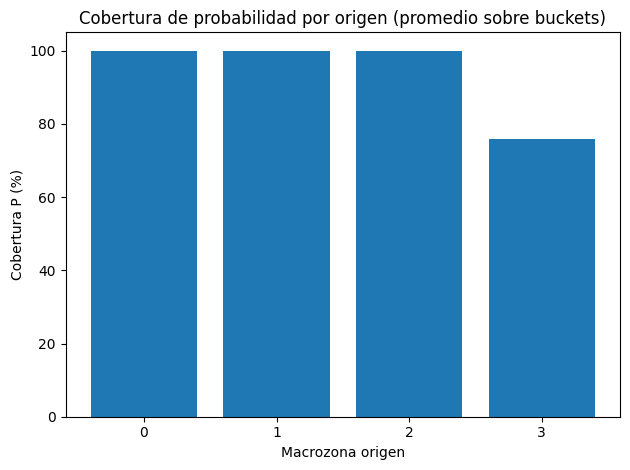


Cobertura por (origen, bucket) — primeras filas:
   macrozona_origen  bucket  P_tot     P_inA       cov_%
0                 0       0    1.0  1.000000  100.000000
1                 1       0    1.0  1.000000  100.000000
2                 2       0    1.0  1.000000  100.000000
3                 3       0    1.0  0.757613   75.761267


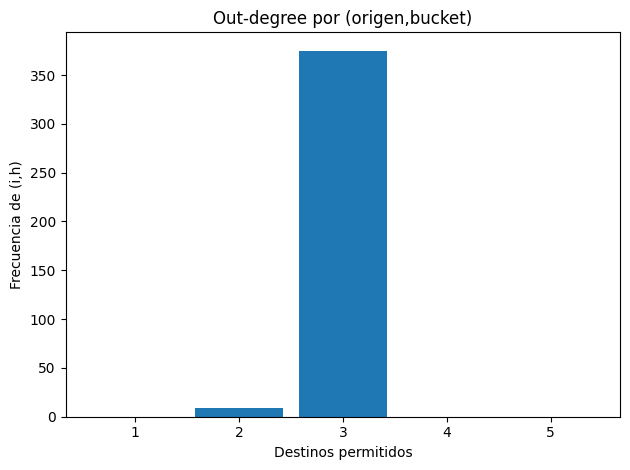


Out-degree por (origen,bucket) — primeras filas:
     macrozona_origen  bucket  outdeg
323                 3      35       2
325                 3      37       2
326                 3      38       2
327                 3      39       2
328                 3      40       2
343                 3      55       2
346                 3      58       2
353                 3      65       2
354                 3      66       2
0                   0       0       3
1                   0       1       3
2                   0       2       3
3                   0       3       3
4                   0       4       3
5                   0       5       3
6                   0       6       3
7                   0       7       3
8                   0       8       3
9                   0       9       3
10                  0      10       3


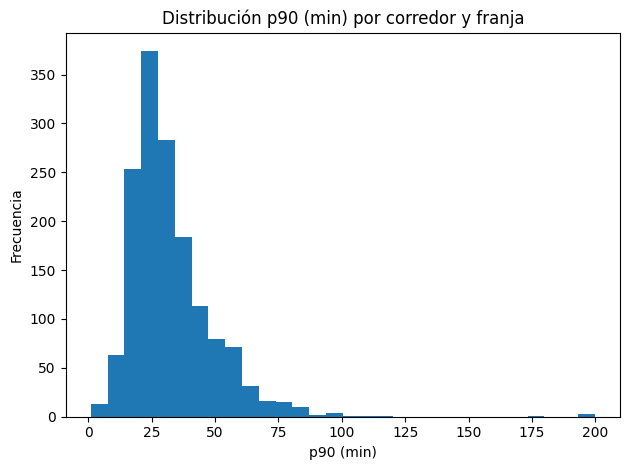


Top 15 corredores con p90 más alto:
      macrozona_origen  macrozona_destino  bucket        p50         p90
1273                 3                  1      28  23.258333  199.766667
1274                 3                  1      29  36.450000  194.646667
719                  1                  3      48  22.075000  194.310000
721                  1                  3      50  22.683333  179.390000
1388                 3                  2      58  45.400000  119.880000
1112                 2                  3      59  54.350000  107.066667
1370                 3                  2      40  43.400000  105.020000
1120                 2                  3      67  68.741667   98.470000
1117                 2                  3      64  65.633333   97.500000
1111                 2                  3      58  53.000000   97.450000
1116                 2                  3      63  59.508333   96.790000
1113                 2                  3      60  50.333333   91.943333
1123          

In [86]:
# === Visuales simples SIN caas_jupyter_tools ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("/content/outputs")
pu, dj, bk = "macrozona_origen", "macrozona_destino", "bucket"

# Rutas
p_A  = OUT/"A_final_SLA_soft_BUCKETS_covgoal.csv"
p_MK = OUT/"markov_normalized.csv"
p_TM = OUT/"times_macro_macro_bucket.csv"

def ensure_bucket(df):
    if bk not in df.columns:
        df = df.copy()
        df[bk] = 0
    return df

# 1) Cobertura de P por origen
try:
    A  = ensure_bucket(pd.read_csv(p_A))
    MK = ensure_bucket(pd.read_csv(p_MK))

    base = MK.groupby([pu,bk])["P"].sum().reset_index(name="P_tot")
    inA  = MK.merge(A.assign(inA=1), on=[pu,dj,bk], how="left").fillna({"inA":0})
    capP = inA[inA["inA"]==1].groupby([pu,bk])["P"].sum().reset_index(name="P_inA")
    cov  = base.merge(capP, on=[pu,bk], how="left").fillna({"P_inA":0})
    cov["cov_%"] = 100*cov["P_inA"]/cov["P_tot"].replace(0,np.nan)
    cov_origen = cov.groupby(pu)["cov_%"].mean().reset_index().sort_values("cov_%", ascending=False)

    # Plot
    plt.figure()
    plt.bar(cov_origen[pu].astype(str), cov_origen["cov_%"])
    plt.title("Cobertura de probabilidad por origen (promedio sobre buckets)")
    plt.xlabel("Macrozona origen"); plt.ylabel("Cobertura P (%)")
    plt.tight_layout(); plt.show()

    # Si quieres ver la tabla:
    print("\nCobertura por (origen, bucket) — primeras filas:")
    print(cov.sort_values([pu,bk]).head(20))
except Exception as e:
    print("Saltando figura 1 (Cobertura). Motivo:", e)

# 2) Histograma del out-degree
try:
    A  = ensure_bucket(pd.read_csv(p_A))
    outdeg = A.groupby([pu,bk])[dj].nunique().rename("outdeg").reset_index()

    plt.figure()
    outdeg["outdeg"].plot(kind="hist", bins=[1,2,3,4,5,6], align="left", rwidth=0.85,
                          title="Out-degree por (origen,bucket)")
    plt.xlabel("Destinos permitidos"); plt.ylabel("Frecuencia de (i,h)")
    plt.tight_layout(); plt.show()

    print("\nOut-degree por (origen,bucket) — primeras filas:")
    print(outdeg.sort_values(["outdeg",pu,bk]).head(20))
except Exception as e:
    print("Saltando figura 2 (Out-degree). Motivo:", e)

# 3) Distribución p90 (SLA)
try:
    TM = pd.read_csv(p_TM).dropna(subset=["p90"])

    plt.figure()
    TM["p90"].plot(kind="hist", bins=30, title="Distribución p90 (min) por corredor y franja")
    plt.xlabel("p90 (min)"); plt.ylabel("Frecuencia")
    plt.tight_layout(); plt.show()

    slow = TM.sort_values("p90", ascending=False).head(15)
    print("\nTop 15 corredores con p90 más alto:")
    print(slow)
except Exception as e:
    print("Saltando figura 3 (p90). Motivo:", e)

# 4) Top-3 destinos por origen (intuición)
try:
    MK = ensure_bucket(pd.read_csv(p_MK))
    mk2 = MK.groupby([pu, dj])["P"].mean().reset_index()
    mk2["rank"] = mk2.groupby(pu)["P"].rank(ascending=False, method="first")
    top3 = mk2[mk2["rank"]<=3].sort_values([pu,"rank"])

    print("\nTop-3 destinos por origen (promedio sobre buckets):")
    print(top3[[pu,dj,"P","rank"]].head(30))
except Exception as e:
    print("Saltando tabla Top-3. Motivo:", e)
